In [1]:
import pandas as pd
import os

# Dosyanın tam yerini bulalım
dosya_yolu = 'Mall_Customers.csv'

# Eğer dosya alt klasördeyse onu da kontrol etsin
if not os.path.exists(dosya_yolu):
    dosya_yolu = 'Customer-Segmentation-Analysis/Mall_Customers.csv'

df = pd.read_csv(dosya_yolu)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


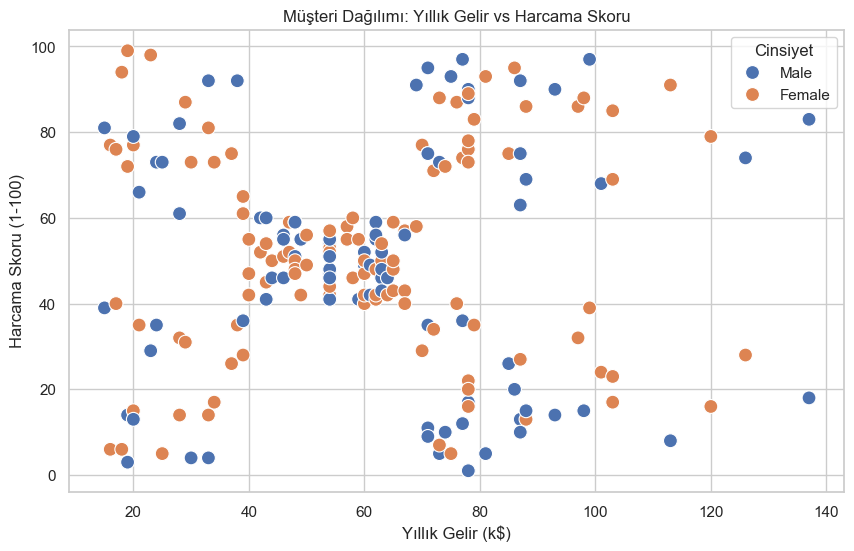

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik stilini belirleyelim
sns.set(style="whitegrid")

# Gelir vs Harcama Skoru Saçılım Grafiği
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', s=100)

plt.title('Müşteri Dağılımı: Yıllık Gelir vs Harcama Skoru')
plt.xlabel('Yıllık Gelir (k$)')
plt.ylabel('Harcama Skoru (1-100)')
plt.legend(title='Cinsiyet')
plt.show()

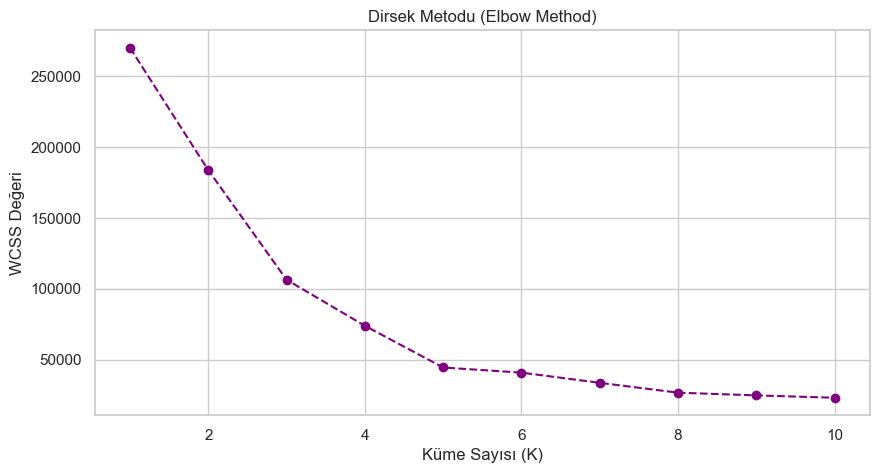

In [3]:
from sklearn.cluster import KMeans

# Analiz için Gelir ve Harcama Skoru sütunlarını seçiyoruz
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []
# 1'den 10'a kadar küme sayılarını deneyip hata oranlarını (wcss) hesaplayalım
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Dirsek grafiğini çizelim
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='purple', linestyle='--')
plt.title('Dirsek Metodu (Elbow Method)')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('WCSS Değeri')
plt.show()

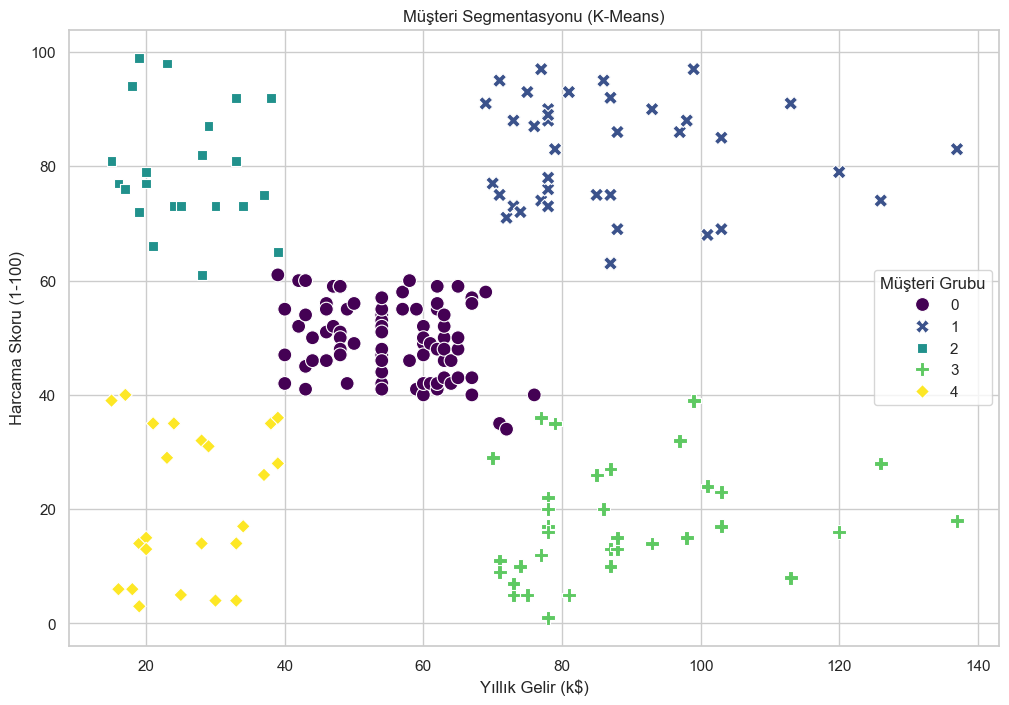

In [ ]:
# Modeli 5 küme ile kuruyoruz
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Sonuçları görselleştirelim 
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', palette='viridis', s=100, style='Cluster')

plt.title('Müşteri Segmentasyonu (K-Means)')
plt.xlabel('Yıllık Gelir (k$)')
plt.ylabel('Harcama Skoru (1-100)')
plt.legend(title='Müşteri Grubu')
plt.show()

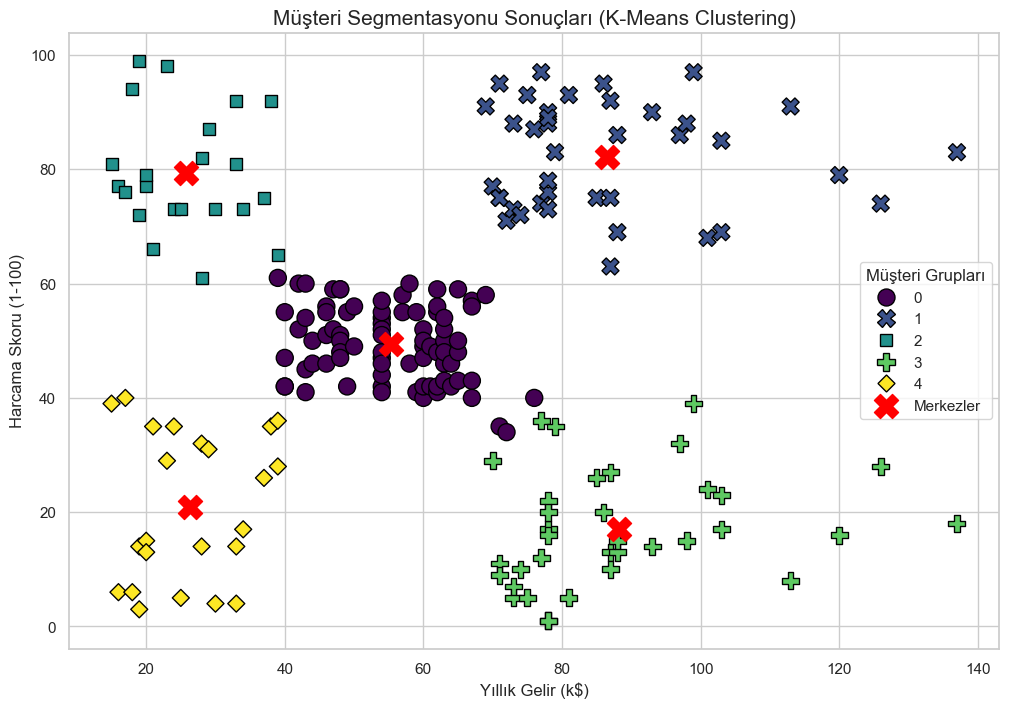

In [ ]:
from sklearn.cluster import KMeans

# 1. Modeli 5 küme olacak şekilde yapılandıralım
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

# 2. Modeli sadece Gelir ve Harcama Skoru verileriyle eğitelim
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
y_kmeans = kmeans.fit_predict(X)

# 3. Bu küme bilgilerini ana tablomuza (df) yeni bir sütun olarak ekleyelim
df['Cluster'] = y_kmeans

# 4. Efsanevi Final Grafiği (Müşteri Segmentasyonu Haritası)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', palette='viridis', s=150, style='Cluster', edgecolors='black')

# Merkez noktalarını (Centroids) işaretleyelim 
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', label='Merkezler', marker='X')

plt.title('Müşteri Segmentasyonu Sonuçları (K-Means Clustering)', fontsize=15)
plt.xlabel('Yıllık Gelir (k$)')
plt.ylabel('Harcama Skoru (1-100)')
plt.legend(title='Müşteri Grupları')
plt.show()